# Assignment 6

Assignment – High Frequency Words  Please answer the following questions in an IPython Notebook, posted to GitHub. 
1. Choose a corpus of interest. 
2. How many total unique words are in the corpus?  (Please feel free to define unique words in any interesting, defensible way). 
3. Taking the most common words, how many unique words represent half of the total words in the corpus? 
4. Identify the 200 highest frequency words in this corpus. 
5. Create a graph that shows the relative frequency of these 200 words. 
6. Does the observed relative frequency of these words follow Zipf’s law?  Explain. 7. In what ways do you think the frequency of the words in this corpus differ from “all words in all corpora.” 

### For this assignment, I will analyzing the Bible both new and old testament.
### Data source: https://openbible.com/textfiles/akjv.txt

## Loading libraries

In [12]:
import nltk
import requests
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [13]:
url = 'https://openbible.com/textfiles/akjv.txt'
Bible = requests.get(url)
Bible = Bible.text
print(Bible[:500])


ï»¿AKJV
American King James Version
Genesis 1:1	In the beginning God created the heaven and the earth.
Genesis 1:2	And the earth was without form, and void; and darkness was on the face of the deep. And the Spirit of God moved on the face of the waters.
Genesis 1:3	And God said, Let there be light: and there was light.
Genesis 1:4	And God saw the light, that it was good: and God divided the light from the darkness.
Genesis 1:5	And God called the light Day, and the darkness he called Night. And t


In [14]:
#Stripping the book titles from the actual text:
lines = Bible.split('\n')
verse_lines = []

for line in lines[2:]:
    if '\t' in line:
        verse_text = line.split('\t')[1]
        verse_lines.append(verse_text)

cleaned_raw_bible = "".join(verse_lines)


## Data Cleaning:

In [15]:
#Tokenize the text:
tokens = nltk.word_tokenize(cleaned_raw_bible)
print(f'Total number of tokens {len(tokens)}')
tokens[:20]


Total number of tokens 866279


['In',
 'the',
 'beginning',
 'God',
 'created',
 'the',
 'heaven',
 'and',
 'the',
 'earth.And',
 'the',
 'earth',
 'was',
 'without',
 'form',
 ',',
 'and',
 'void',
 ';',
 'and']

In [16]:
#Remove all numbers and non-alphabets:
clean_tokens = [w for w in clean_tokens if w.isalpha()]

#Remove stop words:
stop_words = set(stopwords.words('english'))
final_clean_tokens = [w for w in clean_tokens if w.lower() not in stop_words]

print('-'*80)
print('Preview after removing the book titles and extra non-word elements')
print(final_clean_tokens[:20])
print(f'Final number of tokens after cleaning {len(final_clean_tokens)}')

--------------------------------------------------------------------------------
Preview after removing the book titles and extra non-word elements
['beginning', 'God', 'created', 'heaven', 'earth', 'without', 'form', 'void', 'darkness', 'face', 'deep', 'Spirit', 'God', 'moved', 'face', 'God', 'said', 'Let', 'light', 'God']
Final number of tokens after cleaning 311502


## The number of unique words in the Bible:

### let's do the counting with the set of tokens with stopwords all removed. The appearances of 'The', 'and', or 'of' do not carry any significant meaning when presented alone. On the contrary, a high frequencies of these stopwords can overshadow the other meaningful words if their counts are not as high.

In [17]:
total_unique = len(set(final_clean_tokens))
print(f'The number of unique words in the Bible before cleaning stopwords: {total_unique}')

The number of unique words in the Bible before cleaning stopwords: 11979


## Taking out the most common words, how many unique words represent half of the total words in the corpus?

In [18]:
half_total = total_unique / 2

fdlist = nltk.FreqDist(final_clean_tokens)

over_half_list = []

for w, num in fdlist.most_common():
    if num > half_total:
        over_half_list.append((w, num))

print(f'Half number of the whole corpus: {half_total}')
print(f'Word(s) that is over half of the corpus: {over_half_list}')

Half number of the whole corpus: 5989.5
Word(s) that is over half of the corpus: [('shall', 11373)]


## Identify the 200 highest frequency words in this corpus

most common top 200 words [('shall', 11373), ('LORD', 5955), ('said', 5252), ('God', 3605), ('man', 2513), ('Israel', 2234), ('came', 2108), ('king', 2099), ('son', 2026), ('people', 1955), ('house', 1879), ('one', 1817), ('come', 1813), ('children', 1762), ('also', 1614), ('land', 1586), ('day', 1544), ('men', 1513), ('went', 1400), ('made', 1398), ('saying', 1386), ('hand', 1336), ('us', 1326), ('even', 1269), ('go', 1258), ('every', 1178), ('may', 1138), ('things', 1089), ('let', 1084), ('sons', 1046), ('say', 1040), ('make', 1032), ('Lord', 980), ('David', 957), ('great', 931), ('among', 905), ('put', 888), ('brought', 872), ('forth', 865), ('Jesus', 865), ('name', 857), ('away', 825), ('two', 815), ('pass', 812), ('know', 807), ('give', 802), ('therefore', 802), ('earth', 799), ('city', 794), ('neither', 776), ('thereof', 775), ('days', 772), ('according', 762), ('Moses', 758), ('took', 749), ('heart', 747), ('Judah', 747), ('behold', 731), ('take', 722), ('see', 685), ('bring', 6

<Axes: title={'center': 'Top 200 words in the Bible'}, xlabel='Samples', ylabel='Counts'>

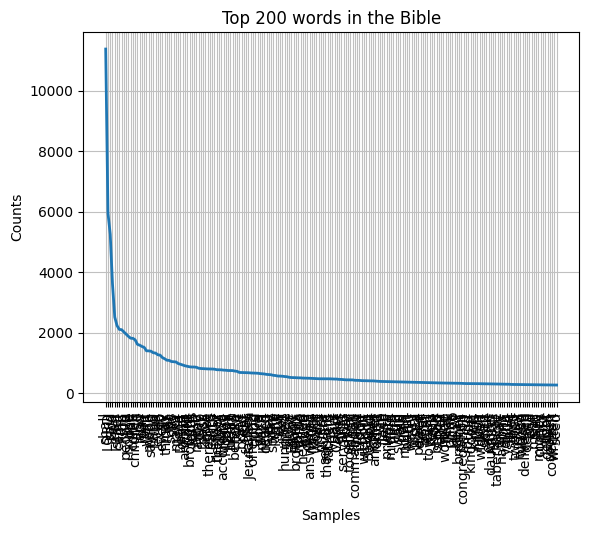

In [19]:
fdlist = nltk.FreqDist(final_clean_tokens)

#Choose only top 20 words
fdlist_200 = fdlist.most_common(200)
print(f'most common top 200 words {fdlist_200}')

#Make a distribution plot:
fdlist.plot(200, title='Top 200 words in the Bible')



The default plot is too messy. Will move the data to seaborn for more fine control:

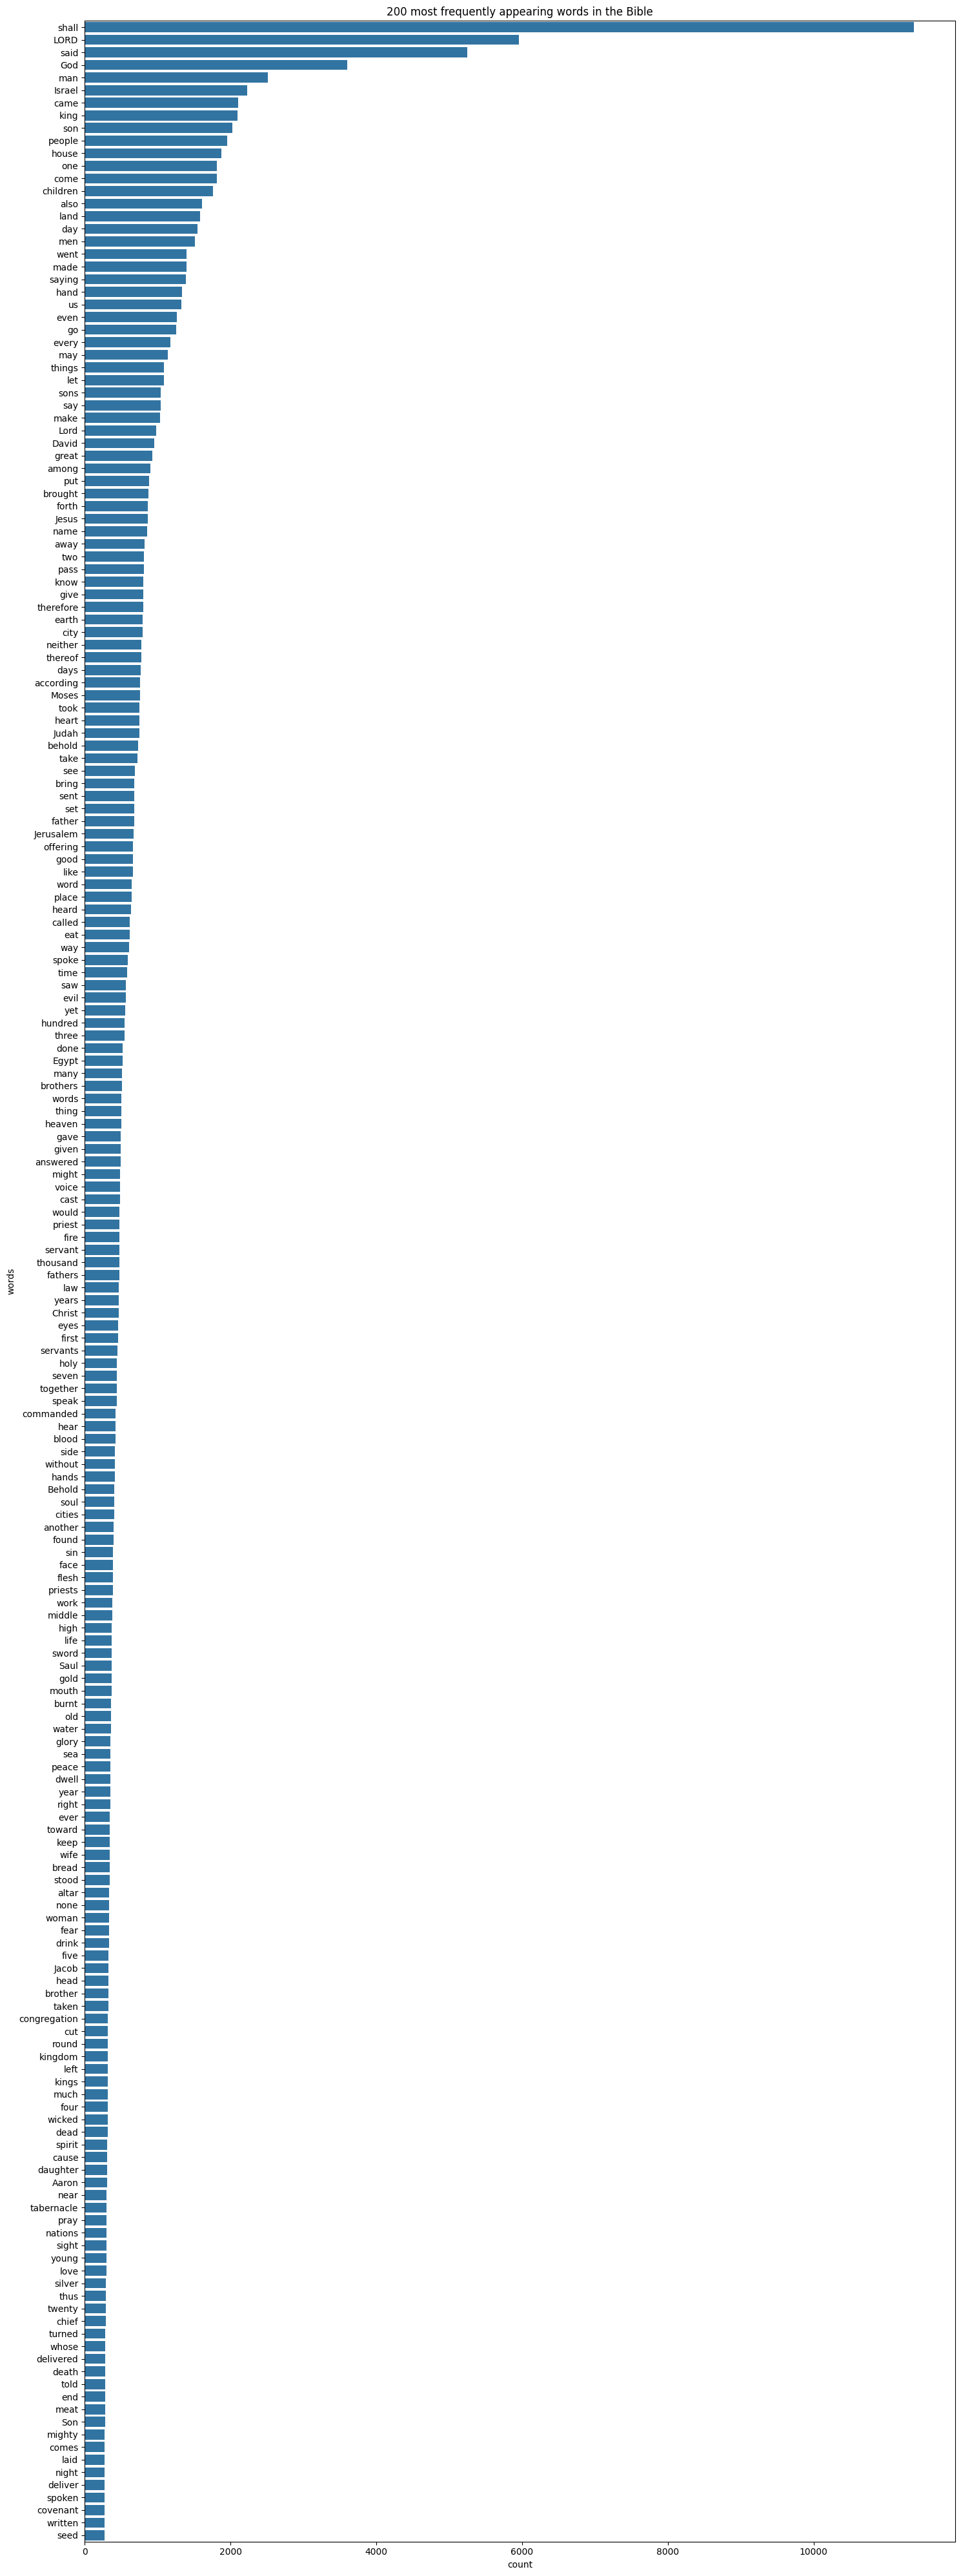

In [20]:
word_count_df = pd.DataFrame(fdlist_200, columns=['words', 'count'])

fig = plt.figure(figsize=(15,40))
sns.barplot(
    word_count_df,
    x = 'count',
    y = 'words'
)
plt.title('200 most frequently appearing words in the Bible')
plt.tight_layout()


## Create a graph that shows the relative frequency of these 200 words.

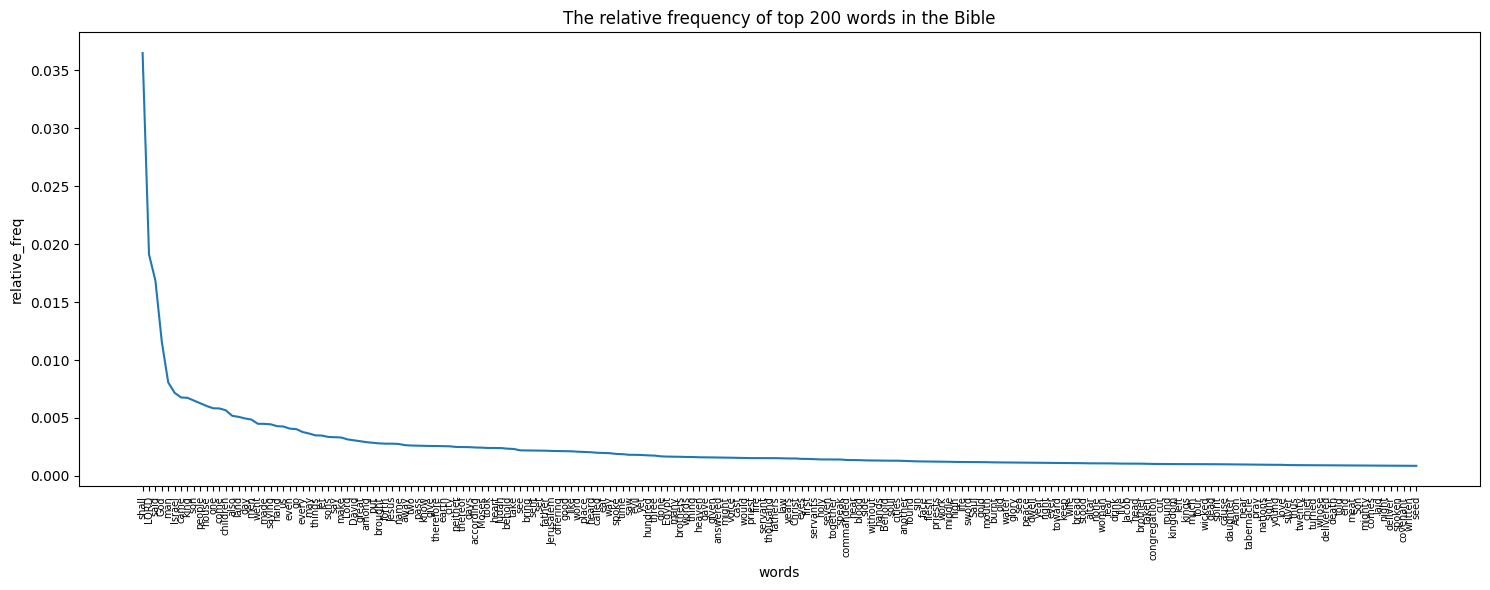

In [21]:
relative_freq_list = {w: fdlist.freq(w) for w, count in fdlist_200}


#Adding the relative frequency to the df
word_count_df['relative_freq'] = word_count_df['words'].map(relative_freq_list) 

#Generate a graph:
plt.figure(figsize=(15, 6))
sns.lineplot(word_count_df, y = 'relative_freq', x = 'words')
plt.tick_params(axis='x', rotation=90, labelsize=7)
plt.title('The relative frequency of top 200 words in the Bible')
plt.tight_layout()


The observed relative frequencies of the top 200 words do follow Zipf's law that the frequency of any word will roughly be inversely proportional to its rank. In other words, the higher the rank (higher in number means less frequent) the less likely we will see the word appearing, forming a long-tail curve as we see in the graph above.

The corpus of the Bible is vastly different from 'all words of all corpora' as shown by the high representation of religious words such as 'Lord', 'God', and 'Israel'. These words reflect the context of this corpus and give a sense to the readers what the content will be most likely to be. Secondly, as the Bible is known to be the words of God for Christianity, it can be interpreted as an instruction manual for mankind and thus the most frequently used word in the Bible is the verb "shall", pointing to actions that humans need to take or to follow.